# Análisis de pérdida de materias — ciclo anterior

## Paso 1: Pregunta de análisis
¿Qué factores se relacionan con que un estudiante **repruebe una materia**, y es posible **identificar a mitad de ciclo** a quienes están en riesgo?

## Fuente de datos
Simulación de una exportación de Moodle con la misma estructura que devuelve una consulta SQL: una fila por estudiante y materia. Los datos son **sintéticos**, con relaciones realistas, porque los reales son datos personales y su uso requiere autorización según la LOPDP. La simulación incluye datos personales **ficticios** para aplicar el proceso de anonimización antes del análisis.
Los nombres de las actividades siguen el formato del calificador , organizado por los componentes de aprendizaje del Reglamento de Régimen Académico (CES): asistido por el profesor (PRF), práctico-experimental (PAE) y aprendizaje autónomo (AA). Los temas, fechas y calificaciones son sintéticos.

## Alcance
El análisis se enfoca en los **niveles 1 a 5** (primeros semestres), porque es donde suele concentrarse la pérdida de materias y el abandono, y donde una **alerta temprana** tiene más impacto. Los niveles superiores (6 a 8) tienen otra dinámica (prácticas preprofesionales, titulación e integración curricular) y quedan como **trabajo futuro**, para comprobar si la reprobación realmente es menor ahí.

### Paso 2 · Estructura y preparacion

In [1]:
import pandas as pd

df = pd.read_csv("data/crudos/evea_export_simulado.csv")
df.head()

,student_id,username,firstname,lastname,email,course_id,course_code,course_name,first_course_access,last_course_access,evaluacion,tipo_evaluacion,nota_obtenida,nota_maxima,porcentaje,fecha_calificacion
0,10000,juan.perez0000@est.ejemplo.edu.ec,JUAN MARÍA,PÉREZ REYES,juan.perez0000@est.ejemplo.edu.ec,3000,01/2026C1/P/03/210-01/1/000066-1A,CÁLCULO DIFERENCIAL - 1A,18/03/2026 18:58,07/08/2026 18:46,Evaluación diagnóstica,mod,NaN,1.0,NaN,NaN
1,10000,juan.perez0000@est.ejemplo.edu.ec,JUAN MARÍA,PÉREZ REYES,juan.perez0000@est.ejemplo.edu.ec,3000,01/2026C1/P/03/210-01/1/000066-1A,CÁLCULO DIFERENCIAL - 1A,18/03/2026 18:58,07/08/2026 18:46,ASISTIDO POR EL PROFESOR: PRF ││ 10 PTOS ││ Ta...,mod,0.88,1.0,87.64,17/05/2026 14:16
2,10000,juan.perez0000@est.ejemplo.edu.ec,JUAN MARÍA,PÉREZ REYES,juan.perez0000@est.ejemplo.edu.ec,3000,01/2026C1/P/03/210-01/1/000066-1A,CÁLCULO DIFERENCIAL - 1A,18/03/2026 18:58,07/08/2026 18:46,ASISTIDO POR EL PROFESOR: PRF ││ 10 PTOS ││ Ta...,mod,0.69,1.0,69.22,24/05/2026 14:01
3,10000,juan.perez0000@est.ejemplo.edu.ec,JUAN MARÍA,PÉREZ REYES,juan.perez0000@est.ejemplo.edu.ec,3000,01/2026C1/P/03/210-01/1/000066-1A,CÁLCULO DIFERENCIAL - 1A,18/03/2026 18:58,07/08/2026 18:46,ASISTIDO POR EL PROFESOR: PRF ││ 10 PTOS ││ Cu...,mod,0.83,1.0,83.41,07/06/2026 10:44
4,10000,juan.perez0000@est.ejemplo.edu.ec,JUAN MARÍA,PÉREZ REYES,juan.perez0000@est.ejemplo.edu.ec,3000,01/2026C1/P/03/210-01/1/000066-1A,CÁLCULO DIFERENCIAL - 1A,18/03/2026 18:58,07/08/2026 18:46,ASISTIDO POR EL PROFESOR: PRF ││ 10 PTOS ││ Ca...,mod,0.88,1.0,87.81,06/06/2026 20:14


In [30]:
print(df.shape)
df.info()
df.tail()

(51240, 16)
<class 'pandas.DataFrame'>
RangeIndex: 51240 entries, 0 to 51239
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           51240 non-null  int64  
 1   username             51240 non-null  str    
 2   firstname            51240 non-null  str    
 3   lastname             51240 non-null  str    
 4   email                51240 non-null  str    
 5   course_id            51240 non-null  int64  
 6   course_code          51240 non-null  str    
 7   course_name          51240 non-null  str    
 8   first_course_access  51240 non-null  str    
 9   last_course_access   51240 non-null  str    
 10  evaluacion           51240 non-null  str    
 11  tipo_evaluacion      51240 non-null  str    
 12  nota_obtenida        43576 non-null  float64
 13  nota_maxima          51240 non-null  float64
 14  porcentaje           43576 non-null  float64
 15  fecha_calificacion   43576 non-null

,student_id,username,firstname,lastname,email,course_id,course_code,course_name,first_course_access,last_course_access,evaluacion,tipo_evaluacion,nota_obtenida,nota_maxima,porcentaje,fecha_calificacion
51235,10499,juan.cardenas0499@est.ejemplo.edu.ec,JUAN ANA,CÁRDENAS GUERRERO,juan.cardenas0499@est.ejemplo.edu.ec,3110,01/2026C1/P/05/167-02/3/000187-3B,NEUROCIENCIAS - 3B,15/03/2026 20:42,30/07/2026 20:16,ASISTIDO POR EL PROFESOR: PRF ││ 10 PTOS ││ Cu...,mod,1.00,1.0,100.00,07/08/2026 09:53
51236,10170,ana.molina0170@est.ejemplo.edu.ec,ANA MATEO,MOLINA LEÓN,ana.molina0170@est.ejemplo.edu.ec,3254,01/2026C1/P/01/101-01/5/000132-5A,FISIOLOGÍA - 5A,15/03/2026 15:30,01/08/2026 16:13,APRENDIZAJE AUTÓNOMO: AA ││ 10 PTOS ││ PRUEBA ...,mod,0.89,1.0,88.88,07/07/2026 15:11
51237,10107,andres.molina0107@est.ejemplo.edu.ec,ANDRÉS JORGE,MOLINA OCHOA,andres.molina0107@est.ejemplo.edu.ec,3011,01/2026C1/P/01/101-01/2/000165-2B,METODOLOGÍA DE LA INVESTIGACIÓN - 2B,21/03/2026 18:28,30/07/2026 16:33,Aplicar los contenidos de la asignatura en la ...,mod,0.86,1.5,57.01,06/08/2026 14:26
51238,10645,paula.zambrano0645@est.ejemplo.edu.ec,PAULA PABLO,ZAMBRANO SERRANO,paula.zambrano0645@est.ejemplo.edu.ec,3231,01/2026C1/P/05/167-02/4/000165-4B,METODOLOGÍA DE LA INVESTIGACIÓN - 4B,23/03/2026 19:03,03/08/2026 19:19,ASISTIDO POR EL PROFESOR: PRF ││ 10 PTOS ││ Ta...,mod,0.93,1.0,93.15,09/07/2026 15:58
51239,10420,ana.calle0420@est.ejemplo.edu.ec,ANA SOFÍA,CALLE LEÓN,ana.calle0420@est.ejemplo.edu.ec,3198,01/2026C1/P/01/101-01/4/000132-4A,FISIOLOGÍA - 4A,13/04/2026 15:37,05/08/2026 16:34,ASISTIDO POR EL PROFESOR: PRF ││ 10 PTOS ││ Ta...,mod,0.59,1.0,58.88,09/06/2026 08:10


In [29]:
df.describe()

,student_id,course_id,nota_obtenida,nota_maxima,porcentaje
count,51240.000000,51240.000000,43576.000000,51240.000000,43576.000000
mean,10399.479391,3133.571233,1.593022,1.875127,82.394936
std,230.941818,81.064600,2.736978,3.262267,15.320557
min,10000.000000,3000.000000,0.000000,1.000000,0.000000
25%,10199.000000,3063.000000,0.760000,1.000000,73.880000
50%,10399.500000,3127.000000,0.880000,1.000000,84.770000
75%,10599.000000,3204.000000,1.000000,1.000000,94.520000
max,10799.000000,3279.000000,14.500000,14.500000,100.000000


2.1 Anonimización (LOPDP)

Antes de analizar, se elimina los datos personales para proteger la identidad de los estudiantes:
- Se borra `firstname`, `lastname` y `username` , porque identifican directamente a la persona.
- La cédula que es el dato de idnumber se reemplaza por un código con **hash SHA-256 y una sal secreta** (`id_estudiante`). Así se puede saber qué filas son del mismo estudiante sin saber quién es, y sin la sal no se puede recuperar la cédula.

In [3]:
import hashlib

SAL = "mi-frase-secreta-2026"

def seudonimo(valor):
    return hashlib.sha256((SAL + str(valor)).encode()).hexdigest()[:12]

datos = df.copy()
datos["id_estudiante"] = datos["student_id"].apply(seudonimo)
datos = datos.drop(columns=["student_id", "username", "firstname", "lastname", "email"])

datos.head()

,course_id,course_code,course_name,first_course_access,last_course_access,evaluacion,tipo_evaluacion,nota_obtenida,nota_maxima,porcentaje,fecha_calificacion,id_estudiante
0,3000,01/2026C1/P/03/210-01/1/000066-1A,CÁLCULO DIFERENCIAL - 1A,18/03/2026 18:58,07/08/2026 18:46,Evaluación diagnóstica,mod,NaN,1.0,NaN,NaN,8d7142d72d2d
1,3000,01/2026C1/P/03/210-01/1/000066-1A,CÁLCULO DIFERENCIAL - 1A,18/03/2026 18:58,07/08/2026 18:46,ASISTIDO POR EL PROFESOR: PRF ││ 10 PTOS ││ Ta...,mod,0.88,1.0,87.64,17/05/2026 14:16,8d7142d72d2d
2,3000,01/2026C1/P/03/210-01/1/000066-1A,CÁLCULO DIFERENCIAL - 1A,18/03/2026 18:58,07/08/2026 18:46,ASISTIDO POR EL PROFESOR: PRF ││ 10 PTOS ││ Ta...,mod,0.69,1.0,69.22,24/05/2026 14:01,8d7142d72d2d
3,3000,01/2026C1/P/03/210-01/1/000066-1A,CÁLCULO DIFERENCIAL - 1A,18/03/2026 18:58,07/08/2026 18:46,ASISTIDO POR EL PROFESOR: PRF ││ 10 PTOS ││ Cu...,mod,0.83,1.0,83.41,07/06/2026 10:44,8d7142d72d2d
4,3000,01/2026C1/P/03/210-01/1/000066-1A,CÁLCULO DIFERENCIAL - 1A,18/03/2026 18:58,07/08/2026 18:46,ASISTIDO POR EL PROFESOR: PRF ││ 10 PTOS ││ Ca...,mod,0.88,1.0,87.81,06/06/2026 20:14,8d7142d72d2d


2.2 Extraer información del curso

El `course_code` tiene el formato `sede/periodo/modalidad/unidad/carrera-versión/nivel/asignatura-sección`. Se seapara `.str.split("/")` para obtener el **periodo**, el **código de carrera**, el **nivel** y el **paralelo**. La **materia** la obtenemos de `course_name`. Como el nombre de la carrera no viene en el reporte, se agrega con un catálogo usando `.map()`.

In [4]:
partes = datos["course_code"].str.split("/")

datos["periodo"]     = partes.str[1]
datos["carrera_cod"] = partes.str[3] + "/" + partes.str[4]
datos["nivel"]       = partes.str[5].astype(int)
datos["paralelo"]    = partes.str[6].str.split("-").str[1].str[-1]
datos["materia"]     = datos["course_name"].str.rsplit(" - ", n=1).str[0]

datos[["course_code", "periodo", "carrera_cod", "nivel", "paralelo", "materia"]].head()

,course_code,periodo,carrera_cod,nivel,paralelo,materia
0,01/2026C1/P/03/210-01/1/000066-1A,2026C1,03/210-01,1,A,CÁLCULO DIFERENCIAL
1,01/2026C1/P/03/210-01/1/000066-1A,2026C1,03/210-01,1,A,CÁLCULO DIFERENCIAL
2,01/2026C1/P/03/210-01/1/000066-1A,2026C1,03/210-01,1,A,CÁLCULO DIFERENCIAL
3,01/2026C1/P/03/210-01/1/000066-1A,2026C1,03/210-01,1,A,CÁLCULO DIFERENCIAL
4,01/2026C1/P/03/210-01/1/000066-1A,2026C1,03/210-01,1,A,CÁLCULO DIFERENCIAL


In [5]:
catalogo = {
    "01/101-01": "MEDICINA",               "02/145-01": "DERECHO",
    "03/210-01": "INGENIERÍA DE SOFTWARE", "04/132-02": "CONTABILIDAD Y AUDITORÍA",
    "01/188-01": "ENFERMERÍA",             "05/167-02": "PSICOLOGÍA",
    "04/120-03": "ECONOMÍA",
}
datos["carrera"] = datos["carrera_cod"].map(catalogo)
datos["carrera"].value_counts()

carrera
MEDICINA                    9478
CONTABILIDAD Y AUDITORÍA    8772
DERECHO                     7557
PSICOLOGÍA                  6598
INGENIERÍA DE SOFTWARE      6534
ENFERMERÍA                  6534
ECONOMÍA                    5767
Name: count, dtype: int64

2.3 · Extraer información de la actividad

El nombre de cada actividad trae datos importantes dentro del texto. Con `.str.extract` se obtiene el **componente**  y la **fecha de entrega**. 

In [6]:
inicio = pd.Timestamp("2026-03-15")     # primer día del ciclo

datos["componente"] = datos["evaluacion"].str.extract(r":\s*(PRF|PAE|AA)\b")[0]
datos["fecha_entrega"] = pd.to_datetime(
    datos["evaluacion"].str.extract(r"FECHA DE ENTREGA \((\d{2}/\d{2}/\d{4})")[0], dayfirst=True)
datos["semana"] = (datos["fecha_entrega"] - inicio).dt.days // 7 + 1
datos["atrasado"] = datos["evaluacion"].str.contains("(atrasado)", regex=False)

for col in ["first_course_access", "last_course_access", "fecha_calificacion"]:
    datos[col] = pd.to_datetime(datos[col], dayfirst=True)

datos[["evaluacion", "componente", "fecha_entrega", "semana", "atrasado"]].head(8)

,evaluacion,componente,fecha_entrega,semana,atrasado
0,Evaluación diagnóstica,NaN,NaT,NaN,False
1,ASISTIDO POR EL PROFESOR: PRF ││ 10 PTOS ││ Ta...,PRF,2026-04-18,5.0,False
2,ASISTIDO POR EL PROFESOR: PRF ││ 10 PTOS ││ Ta...,PRF,2026-04-16,5.0,False
3,ASISTIDO POR EL PROFESOR: PRF ││ 10 PTOS ││ Cu...,PRF,2026-04-24,6.0,True
4,ASISTIDO POR EL PROFESOR: PRF ││ 10 PTOS ││ Ca...,PRF,2026-04-24,6.0,False
5,APRENDIZAJE AUTÓNOMO: AA ││ 10 PTOS ││ PRUEBA ...,AA,2026-05-16,9.0,False
6,ASISTIDO POR EL PROFESOR: PRF ││ 10 PTOS ││ Ta...,PRF,2026-05-28,11.0,False
7,ASISTIDO POR EL PROFESOR: PRF ││ 10 PTOS ││ Ta...,PRF,2026-05-28,11.0,False


2.4 Convertir a category

Con `nunique()` se revisa cuántos valores distintos tiene cada columna. Las que representan **grupos** (periodo, carrera, paralelo, materia, componente y tipo de evaluación) tienen pocos valores, así que se convierte a `category`: ocupan menos memoria y se agrupan más fácil. Las notas y porcentajes son **numéricas**, y los accesos y fechas de entrega son de tipo **fecha**.

In [7]:
print(datos.nunique())

cats = ["periodo", "carrera", "carrera_cod", "paralelo", "materia", "componente", "tipo_evaluacion"]
datos[cats] = datos[cats].astype("category")
datos.dtypes

course_id                280
course_code              280
course_name              200
first_course_access     2597
last_course_access      2613
evaluacion                81
tipo_evaluacion            2
nota_obtenida           1062
nota_maxima                3
porcentaje              5876
fecha_calificacion     25991
id_estudiante            800
periodo                    1
carrera_cod                7
nivel                      5
paralelo                   2
materia                   20
carrera                    7
componente                 3
fecha_entrega             27
semana                     9
atrasado                   2
dtype: int64


course_id                       int64
course_code                       str
course_name                       str
first_course_access    datetime64[us]
last_course_access     datetime64[us]
evaluacion                        str
tipo_evaluacion              category
nota_obtenida                 float64
nota_maxima                   float64
porcentaje                    float64
fecha_calificacion     datetime64[us]
id_estudiante                     str
periodo                      category
carrera_cod                  category
nivel                           int64
paralelo                     category
materia                      category
carrera                      category
componente                   category
fecha_entrega          datetime64[us]
semana                        float64
atrasado                         bool
dtype: object

2.5 Duplicados


In [8]:
print("Filas antes:", len(datos))
print("Duplicados:", datos.duplicated(["id_estudiante", "course_id", "evaluacion"]).sum())

datos = datos.drop_duplicates(["id_estudiante", "course_id", "evaluacion"])
print("Filas después:", len(datos))

Filas antes: 51240
Duplicados: 40
Filas después: 51200


Paso 2.6 · k-anonimato

In [9]:
cuasi = ["carrera_cod", "nivel", "paralelo"]
por_persona = datos.drop_duplicates("id_estudiante")
tamanos = por_persona.groupby(cuasi, observed=True).size()
print(f"Antes → k = {tamanos.min()} | grupos con menos de 5: {(tamanos < 5).sum()}")

en_riesgo = por_persona.set_index(cuasi).index.isin(tamanos[tamanos < 5].index)
ids_riesgo = por_persona.loc[en_riesgo, "id_estudiante"]
datos = datos[~datos["id_estudiante"].isin(ids_riesgo)]

tamanos = datos.drop_duplicates("id_estudiante").groupby(cuasi, observed=True).size()
print(f"Se suprimieron {len(ids_riesgo)} estudiantes → k = {tamanos.min()} | quedan {datos['id_estudiante'].nunique()}")

Antes → k = 4 | grupos con menos de 5: 2
Se suprimieron 8 estudiantes → k = 5 | quedan 792


Aunque ya no hay nombres, alguien podría ser reconocido si es de los pocos estudiantes de su carrera, nivel y paralelo. Con esas 3 variables, el grupo más pequeño tenía **k = 4** (2 grupos con menos de 5 estudiantes). Suprimí a esos **8 estudiantes** para lograr **k ≥ 5**; quedaron **792**.

### Paso 3 · Univariado- Nota final

In [10]:
finales = datos[datos["tipo_evaluacion"] == "course"].copy()
print(finales.shape)
finales["porcentaje"].describe()

(3168, 22)


count    3168.000000
mean       74.623387
std        21.084489
min         0.000000
25%        67.682500
50%        80.865000
75%        89.440000
max       100.000000
Name: porcentaje, dtype: float64

Media:     74.62
Mediana:   80.87
Asimetría: -1.48


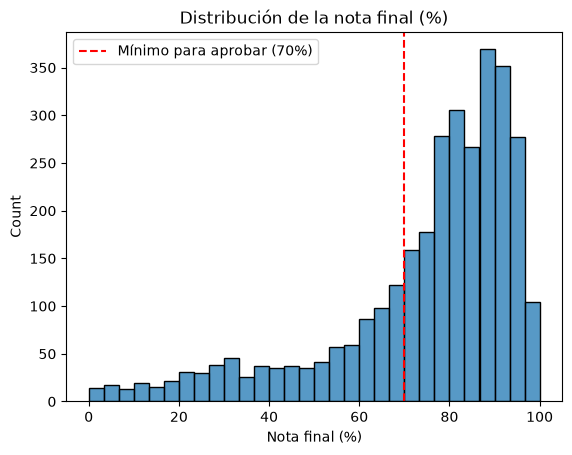

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

nota = finales["porcentaje"]
print(f"Media:     {nota.mean():.2f}")
print(f"Mediana:   {nota.median():.2f}")
print(f"Asimetría: {nota.skew():.2f}")

sns.histplot(nota, bins=30)
plt.axvline(70, color="red", linestyle="--", label="Mínimo para aprobar (70%)")
plt.title("Distribución de la nota final (%)")
plt.xlabel("Nota final (%)")
plt.legend()
plt.show()

In [12]:
finales["estado"] = (finales["porcentaje"] >= 70).map({True: "Aprobado", False: "Reprobado"})
print(finales["estado"].value_counts())
print((finales["estado"].value_counts(normalize=True) * 100).round(1))

estado
Aprobado     2290
Reprobado     878
Name: count, dtype: int64
estado
Aprobado     72.3
Reprobado    27.7
Name: proportion, dtype: float64


La **mediana (80.9 %)** es mayor que la **media (74.7 %)** y la asimetría es **negativa (-1.49)**: la mayoría de estudiantes tiene notas altas, pero hay una **cola hacia la izquierda** de estudiantes con notas muy bajas (algunas en 0 %) que "jalan" la media hacia abajo.
El **27.5 %** de las matrículas terminó **reprobado** (nota < 70 %).

### Paso 3 · Univariado — actividades y primer acceso


In [13]:
actividades = datos[datos["componente"].notna()].copy()
actividades["entregada"] = actividades["nota_obtenida"].notna()

print(actividades.shape)
print(actividades["componente"].value_counts())


(41184, 23)
componente
PRF    25344
AA      9504
PAE     6336
Name: count, dtype: int64


In [14]:
print(f"% entregadas: {actividades['entregada'].mean() * 100:.1f}%")
print(f"% atrasadas:  {actividades['atrasado'].mean() * 100:.1f}%")
print((actividades.groupby("componente", observed=True)["entregada"].mean() * 100).round(1))

% entregadas: 89.2%
% atrasadas:  13.2%
componente
AA     87.8
PAE    87.0
PRF    90.2
Name: entregada, dtype: float64


Media: 83.7 | Mediana: 85.5 | Asimetría: -0.67


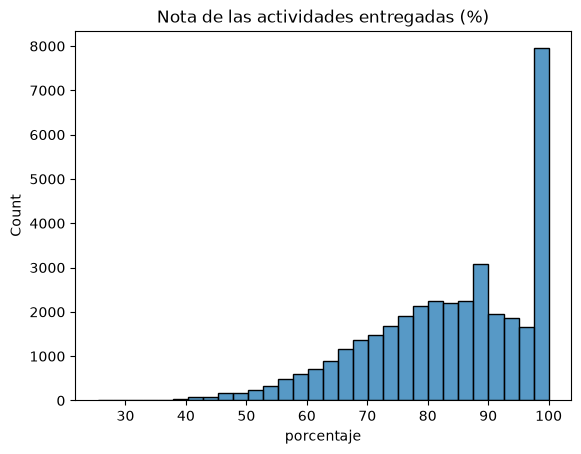

In [15]:
entregadas = actividades[actividades["entregada"]]
print(f"Media: {entregadas['porcentaje'].mean():.1f} | Mediana: {entregadas['porcentaje'].median():.1f} "
      f"| Asimetría: {entregadas['porcentaje'].skew():.2f}")

sns.histplot(entregadas["porcentaje"], bins=30)
plt.title("Nota de las actividades entregadas (%)")
plt.show()

count    3168.000000
mean        5.954230
std         8.247175
min         0.000000
25%         1.000000
50%         3.000000
75%         7.000000
max        61.000000
Name: dias_primer_acceso, dtype: float64
Asimetría: 3.02


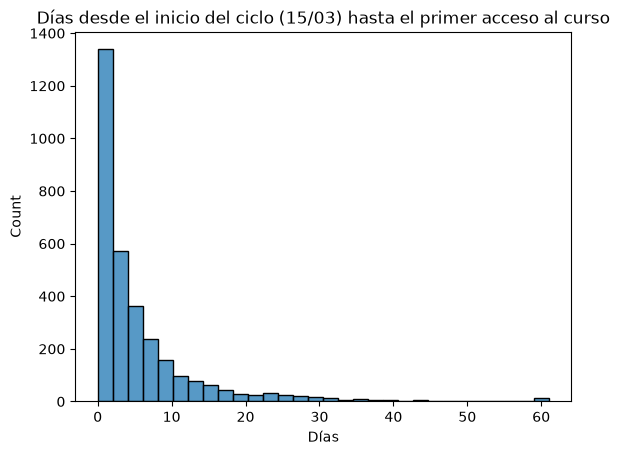

In [16]:
finales["dias_primer_acceso"] = (finales["first_course_access"] - inicio).dt.days
print(finales["dias_primer_acceso"].describe())
print(f"Asimetría: {finales['dias_primer_acceso'].skew():.2f}")

sns.histplot(finales["dias_primer_acceso"], bins=30)
plt.title("Días desde el inicio del ciclo (15/03) hasta el primer acceso al curso")
plt.xlabel("Días")
plt.show()

- Se registraron unas **41.600 actividades** (PRF, PAE y AA). El **89 %** fue entregado y el **13 %** llegó **atrasado**. El componente con menos entregas es el práctico-experimental (PAE, 87 %).
- Las actividades entregadas tienen notas altas (mediana **85.5 %**), con una leve cola hacia la izquierda.
- **Primer acceso al curso:** la mitad de los estudiantes entra en los primeros **3 días**, pero la distribución tiene **asimetría positiva fuerte (3.0)**: unos pocos tardan semanas en entrar (hasta **61 días**). Ese grupo que entra tarde es candidato a estar en riesgo, y lo compruebo en el bivariado.

### Paso 4 · Bivariado

In [17]:
inicio_ciclo = actividades[actividades["semana"] <= 6].copy()
inicio_ciclo["nota_0"] = inicio_ciclo["porcentaje"].fillna(0)     # no entregada = 0

resumen_inicio = (inicio_ciclo
    .groupby(["id_estudiante", "course_id"])
    .agg(entregadas_inicio=("entregada", "mean"),
         promedio_inicio=("nota_0", "mean"))
    .reset_index())
resumen_inicio["entregadas_inicio"] *= 100

finales = finales.merge(resumen_inicio, on=["id_estudiante", "course_id"], how="left")
finales["reprobo"] = (finales["estado"] == "Reprobado").astype(int)
finales[["id_estudiante", "materia", "entregadas_inicio", "promedio_inicio", "porcentaje", "estado"]].head()

,id_estudiante,materia,entregadas_inicio,promedio_inicio,porcentaje,estado
0,8d7142d72d2d,CÁLCULO DIFERENCIAL,100.0,82.0200,83.03,Aprobado
1,8d7142d72d2d,PROGRAMACIÓN I,100.0,84.9125,91.45,Aprobado
2,8d7142d72d2d,BASE DE DATOS,100.0,95.0000,93.98,Aprobado
3,8d7142d72d2d,METODOLOGÍA DE LA INVESTIGACIÓN,100.0,89.3525,91.85,Aprobado
4,0b838856593f,CONTABILIDAD GENERAL,100.0,82.4325,77.89,Aprobado


              % reprobación  matrículas
rango_acceso                           
0-3 días               15.8        1675
4-7 días               27.4         719
8-14 días              39.0         449
Más de 14              74.5         325


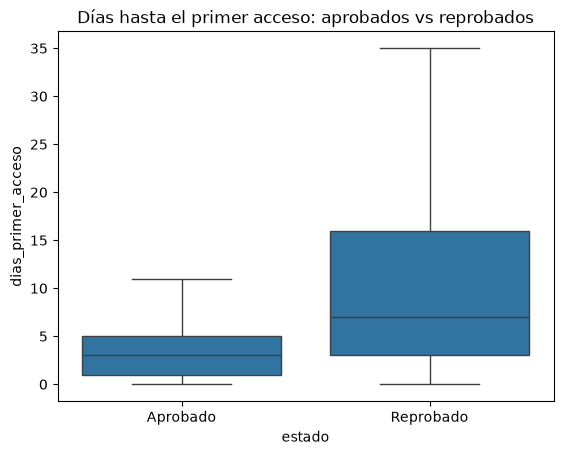

In [18]:
finales["rango_acceso"] = pd.cut(finales["dias_primer_acceso"], [-1, 3, 7, 14, 70],
                                 labels=["0-3 días", "4-7 días", "8-14 días", "Más de 14"])
tabla = finales.groupby("rango_acceso", observed=True)["reprobo"].agg(["mean", "size"])
tabla["mean"] = (tabla["mean"] * 100).round(1)
print(tabla.rename(columns={"mean": "% reprobación", "size": "matrículas"}))

sns.boxplot(data=finales, x="estado", y="dias_primer_acceso", showfliers=False)
plt.title("Días hasta el primer acceso: aprobados vs reprobados")
plt.show()

              % reprobación  matrículas
rango_inicio                           
<50                    98.7         314
50-70                  66.4         443
70-85                  20.1        1005
85-100                  5.1        1406


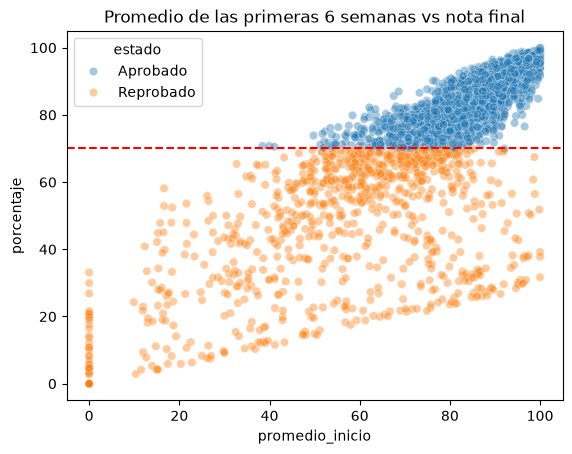

In [19]:
finales["rango_inicio"] = pd.cut(finales["promedio_inicio"], [-1, 50, 70, 85, 100],
                                 labels=["<50", "50-70", "70-85", "85-100"])
tabla2 = finales.groupby("rango_inicio", observed=True)["reprobo"].agg(["mean", "size"])
tabla2["mean"] = (tabla2["mean"] * 100).round(1)
print(tabla2.rename(columns={"mean": "% reprobación", "size": "matrículas"}))

sns.scatterplot(data=finales, x="promedio_inicio", y="porcentaje", hue="estado", alpha=.4)
plt.axhline(70, color="red", linestyle="--")
plt.title("Promedio de las primeras 6 semanas vs nota final")
plt.show()

In [20]:
finales[["dias_primer_acceso", "entregadas_inicio", "promedio_inicio", "porcentaje"]] \
    .corr(method="spearman")["porcentaje"].round(2)

dias_primer_acceso   -0.35
entregadas_inicio     0.57
promedio_inicio       0.83
porcentaje            1.00
Name: porcentaje, dtype: float64

**¿Entrar tarde al curso se relaciona con reprobar?** Sí. Quienes entran en los primeros 3 días reprueban el **15.5 %**, mientras que quienes tardan más de 14 días reprueban el **74.5 %**. La mediana de días hasta el primer acceso es 3 en los aprobados y 7 en los reprobados. La correlación de Spearman es **-0.35**: a más días de retraso, menor nota.

**¿El desempeño de las primeras 6 semanas anticipa el resultado?** Sí, y con mucha fuerza. Con un promedio **menor a 50 %** en esas semanas, reprueba el **98.7 %**; con **85 % o más**, solo el **5 %**. La correlación de Spearman entre el promedio inicial y la nota final es **0.83** (muy fuerte).

**Conclusión:** a las 6 semanas del ciclo ya se puede identificar a la mayoría de estudiantes en riesgo, a tiempo para intervenir.

### Paso 5 · Faltantes y atipicos

In [21]:
faltan = datos.isna().sum()
faltan[faltan > 0]

nota_obtenida         7625
porcentaje            7625
fecha_calificacion    7625
componente            9504
fecha_entrega         9504
semana                9504
dtype: int64

porcentaje: 264 atípicos (límites 35.0 y 122.1)
dias_primer_acceso: 263 atípicos (límites -8.0 y 16.0)


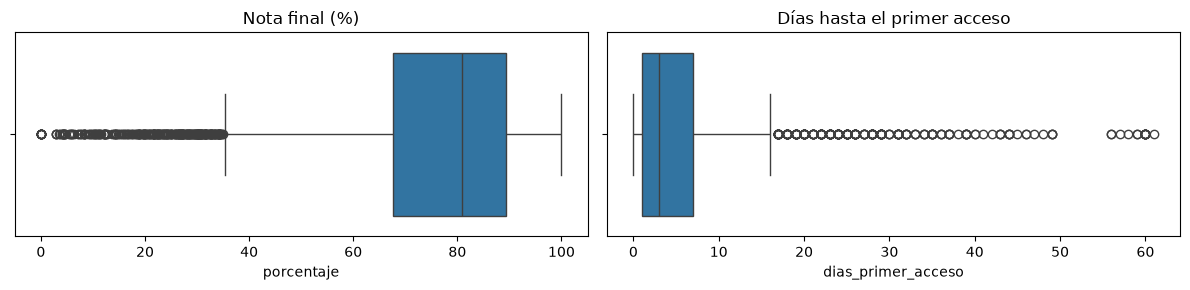

In [22]:
def atipicos_iqr(serie):
    q1, q3 = serie.quantile([.25, .75])
    iqr = q3 - q1
    return ((serie < q1 - 1.5 * iqr) | (serie > q3 + 1.5 * iqr)).sum(), q1 - 1.5 * iqr, q3 + 1.5 * iqr

for col in ["porcentaje", "dias_primer_acceso"]:
    n, li, ls = atipicos_iqr(finales[col])
    print(f"{col}: {n} atípicos (límites {li:.1f} y {ls:.1f})")

fig, ax = plt.subplots(1, 2, figsize=(12, 3))
sns.boxplot(x=finales["porcentaje"], ax=ax[0]).set_title("Nota final (%)")
sns.boxplot(x=finales["dias_primer_acceso"], ax=ax[1]).set_title("Días hasta el primer acceso")
plt.tight_layout(); plt.show()


**Faltantes:** 7.625 actividades no tienen nota (`nota_obtenida`, `porcentaje` y `fecha_calificacion` vacías al mismo tiempo). No es un error: son actividades **no entregadas** (NULL en Moodle). No se eliminan se usan como información y cuentan como 0 en el promedio. Los vacíos en `componente`, `fecha_entrega` y `semana` corresponden a filas que no son actividades (evaluación diagnóstica, resultado de aprendizaje y nota final).

**Atípicos (regla IQR):**
- **Nota final:** 264 atípicos, todos **por debajo de 35 %** (el límite superior, 122.1, está fuera de la escala 0-100). Hay 11 notas en 0 %.
- **Días hasta el primer acceso:** 263 atípicos, todos **por encima de 16 días** (el límite inferior, -8, no existe).

**Decisión: se conserva los atípicos.** No son errores de digitación, sino comportamientos reales: estudiantes que **abandonaron** el curso o que **entraron muy tarde**. Es justamente el grupo en riesgo que se debe identificar. Para que no distorsionen los resultados, usamos la **mediana** y **correlación de Spearman**, que no se dejan afectar por valores extremos.

### Paso 6 · Segmentacion

                          reprobacion  matriculas  mediana_nota
carrera                                                        
MEDICINA                         35.5         592        77.395
ENFERMERÍA                       31.1         392        79.350
INGENIERÍA DE SOFTWARE           28.8         392        78.865
CONTABILIDAD Y AUDITORÍA         26.6         548        82.580
PSICOLOGÍA                       25.0         412        83.755
DERECHO                          22.2         472        83.700
ECONOMÍA                         21.9         360        83.505


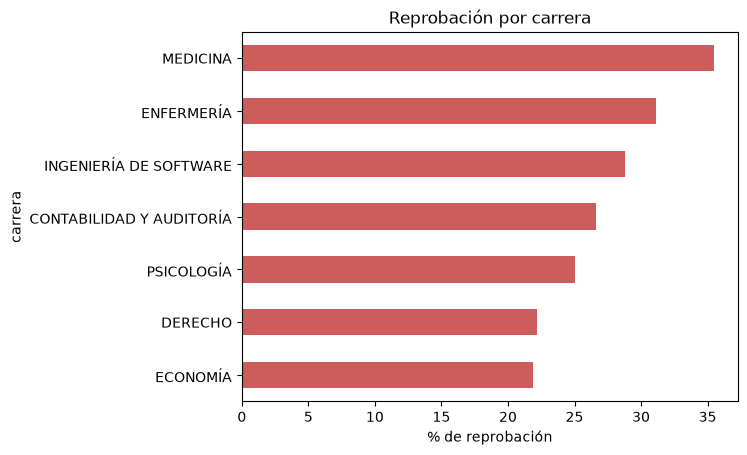

In [23]:
por_carrera = (finales.groupby("carrera", observed=True)
               .agg(reprobacion=("reprobo", "mean"), matriculas=("reprobo", "size"),
                    mediana_nota=("porcentaje", "median"))
               .sort_values("reprobacion", ascending=False))
por_carrera["reprobacion"] = (por_carrera["reprobacion"] * 100).round(1)
print(por_carrera)

por_carrera["reprobacion"].sort_values().plot.barh(color="indianred")
plt.xlabel("% de reprobación"); plt.title("Reprobación por carrera")
plt.show()

In [24]:
por_materia = finales.groupby("materia", observed=True)["reprobo"].agg(["mean", "size"])
por_materia["mean"] = (por_materia["mean"] * 100).round(1)
por_materia.sort_values("mean", ascending=False).head(6)

,mean,size
materia,,
BIOQUÍMICA,43.2,148
CÁLCULO DIFERENCIAL,38.8,98
ANATOMÍA HUMANA,35.4,246
FISIOLOGÍA,32.4,148
PROGRAMACIÓN I,31.6,98
FARMACOLOGÍA,31.6,98


In [25]:
(finales.groupby("nivel")["reprobo"].mean() * 100).round(1)

nivel
1    32.8
2    27.1
3    26.7
4    29.0
5    23.2
Name: reprobo, dtype: float64

rango_acceso              0-3 días  4-7 días  8-14 días  Más de 14
carrera                                                           
CONTABILIDAD Y AUDITORÍA      14.1      26.2       37.8       77.8
DERECHO                       12.4      20.5       36.9       61.4
ECONOMÍA                      12.7      17.9       34.0       68.8
ENFERMERÍA                    18.9      28.6       33.9       84.4
INGENIERÍA DE SOFTWARE        18.0      28.3       36.7       71.1
MEDICINA                      20.0      41.0       46.9       80.6
PSICOLOGÍA                    14.0      21.8       43.3       71.1


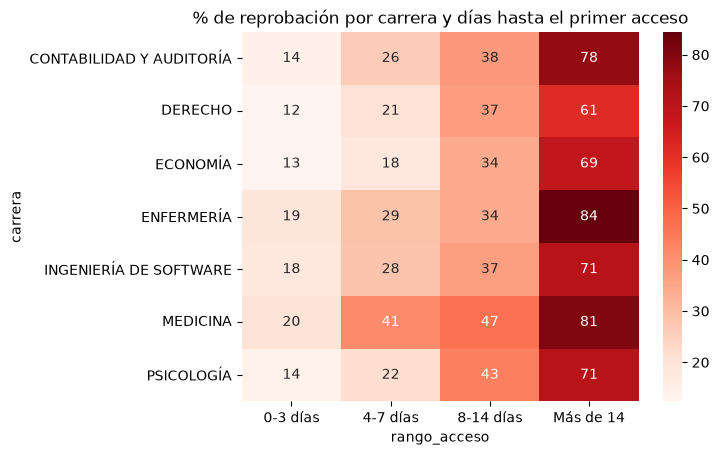

In [26]:
tabla = pd.pivot_table(finales, values="reprobo", index="carrera", columns="rango_acceso",
                       aggfunc="mean", observed=True) * 100
print(tabla.round(1))

sns.heatmap(tabla, annot=True, fmt=".0f", cmap="Reds")
plt.title("% de reprobación por carrera y días hasta el primer acceso")
plt.show()

In [27]:
perdidas = finales.groupby("id_estudiante")["reprobo"].sum()
perdidas.value_counts().sort_index()

reprobo
0    430
1    121
2     71
3     65
4    105
Name: count, dtype: int64

- **Por carrera:** la reprobación va de **21.9 %** (Economía) a **35.5 %** (Medicina). Las carreras de salud (Medicina y Enfermería) tienen la reprobación más alta.
- **Por materia:** las más difíciles son **Bioquímica (43.2 %)**, **Cálculo Diferencial (38.8 %)** y **Anatomía Humana (35.4 %)**.
- **Por nivel:** el **primer nivel** tiene la reprobación más alta (**32.8 %**) y baja en niveles superiores (23.2 % en 5.º): los estudiantes nuevos necesitan más acompañamiento.
- **Carrera × primer acceso:** en **todas las carreras** se repite el patrón: entrar tarde multiplica la reprobación (de 12-20 % a 61-84 %). El primer acceso es una señal de alerta que sirve para cualquier carrera.
- **Materias perdidas por estudiante:** 430 estudiantes (54 %) aprueban todo, pero **105 pierden las 4 materias**: la pérdida se concentra en un grupo de estudiantes, probablemente los que **abandonan**.

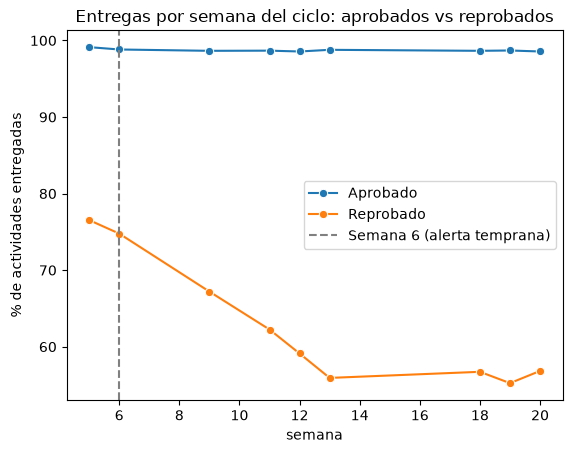

In [28]:
act = actividades.merge(finales[["id_estudiante", "course_id", "estado"]],
                        on=["id_estudiante", "course_id"])
semanal = (act.groupby(["semana", "estado"])["entregada"].mean() * 100).reset_index()

sns.lineplot(data=semanal, x="semana", y="entregada", hue="estado", marker="o")
plt.axvline(6, color="gray", linestyle="--", label="Semana 6 (alerta temprana)")
plt.ylabel("% de actividades entregadas")
plt.title("Entregas por semana del ciclo: aprobados vs reprobados")
plt.legend(); plt.show()

### Paso 7 · Hallazgos

1. Quienes entran al curso en los primeros 3 días reprueban cerca del 16 %; quienes tardan más de 2 semanas, cerca del 75 %. Esto se repite en todas las carreras.

2. Un estudiante con un promedio menor a 50 % en sus primeras actividades casi siempre termina reprobando; uno con más de 85 % casi nunca. A la semana 6 ya se puede saber quién necesita ayuda, con tiempo para ayudarlo.

3. Los estudiantes de primer nivel y las carreras de salud (Medicina y Enfermería) reprueban más, y materias como Bioquímica y Cálculo Diferencial son las más difíciles. Además, 105 estudiantes perdieron sus 4 materias: probablemente abandonaron el ciclo.


> ⚠️ **Limitación:** los datos son sintéticos y las relaciones entre variables fueron definidas al simularlos. Los resultados muestran que el **método** detecta las señales de riesgo; la magnitud real de cada efecto solo se sabrá al aplicar el mismo análisis a los datos reales de EVEA.